### OPERASI PIXEL

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Membaca Data & Gambar 1 (Asli)

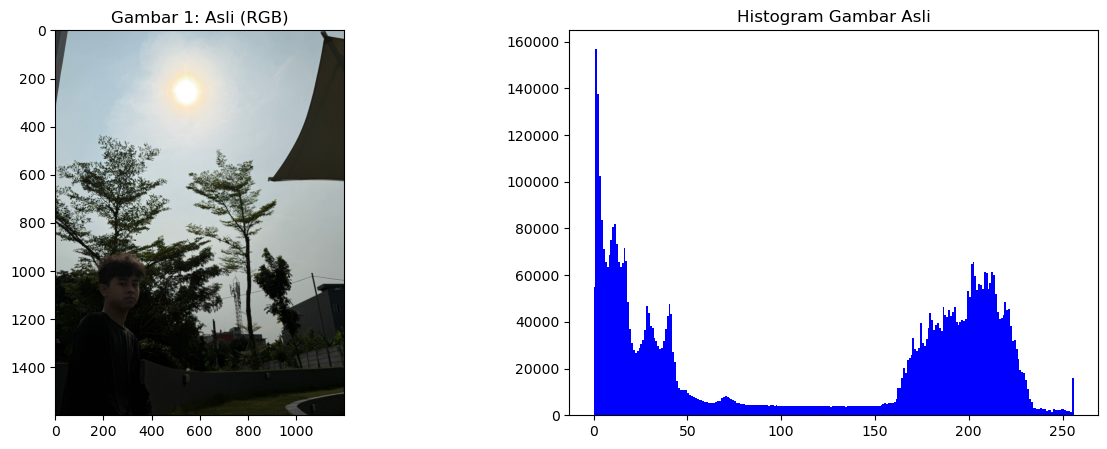

In [3]:
img = cv2.imread("202431005_Muhammad Hafizh Wijdan_Operasi Pixel.jpg")
[baris, kolom] = img.shape[:2]
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Tampilkan Gambar 1 (Asli) dan Histogram
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].imshow(rgb)
axs[0].set_title("Gambar 1: Asli (RGB)")
axs[1].hist(rgb.ravel(), bins=256, range=[0, 256], color='blue')
axs[1].set_title("Histogram Gambar Asli")
plt.show()

### Gambar 2: Konversi Grayscale

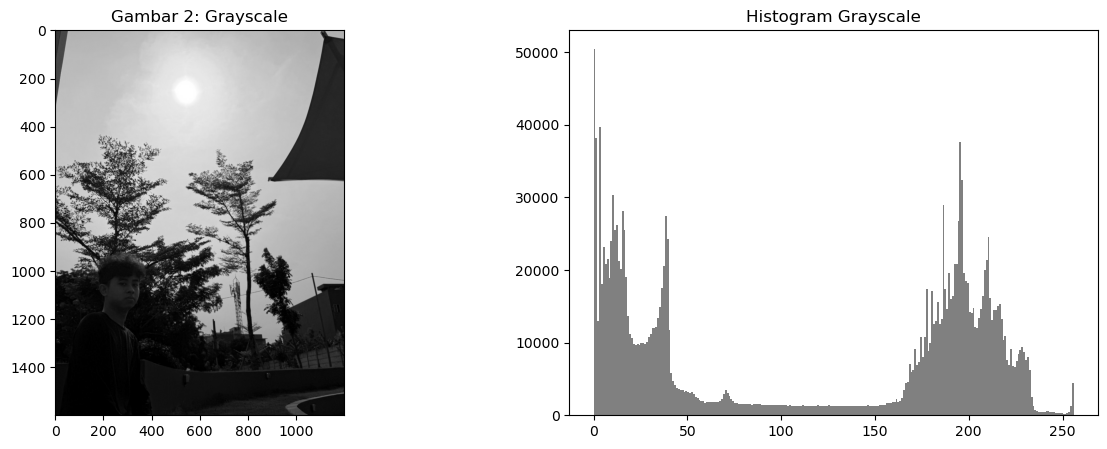

In [4]:
gray = np.zeros((baris, kolom), dtype=np.uint8)

for x in range(baris):
    for y in range(kolom):
        r = rgb[x, y, 0]
        g = rgb[x, y, 1]
        b = rgb[x, y, 2]
        # Rumus luminance standar
        f = 0.299 * r + 0.587 * g + 0.114 * b
        gray[x, y] = int(f)

cv2.imwrite("Gambar_2_Grayscale.jpg", gray)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].imshow(gray, cmap='gray')
axs[0].set_title("Gambar 2: Grayscale")
axs[1].hist(gray.ravel(), bins=256, range=[0, 256], color='gray')
axs[1].set_title("Histogram Grayscale")
plt.show()

### Gambar 3: Operasi Kecerahan (Beta)


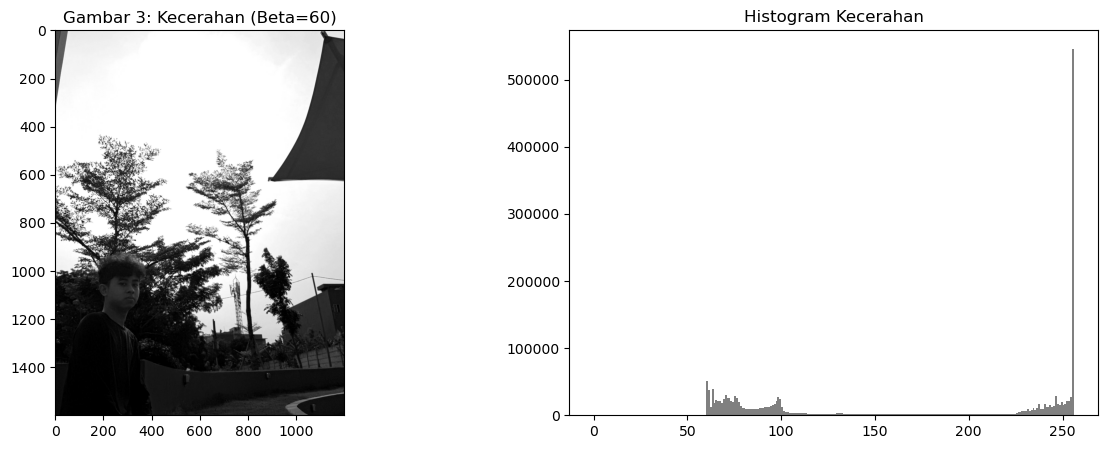

In [5]:
beta = 60
citra_cerah = np.zeros((baris, kolom), dtype=np.float64)

for x in range(baris):
    for y in range(kolom):
        # PENTING: Cast ke float untuk menghindari overflow sebelum np.clip
        gyx = float(gray[x, y]) + beta
        citra_cerah[x, y] = gyx

citra_cerah = np.clip(citra_cerah, 0, 255).astype(np.uint8)

cv2.imwrite("Gambar_3_Kecerahan.jpg", citra_cerah)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].imshow(citra_cerah, cmap='gray')
axs[0].set_title(f"Gambar 3: Kecerahan (Beta={beta})")
axs[1].hist(citra_cerah.ravel(), bins=256, range=[0, 256], color='gray')
axs[1].set_title("Histogram Kecerahan")
plt.show()

### Gambar 4: Operasi Kontras (Alpha)

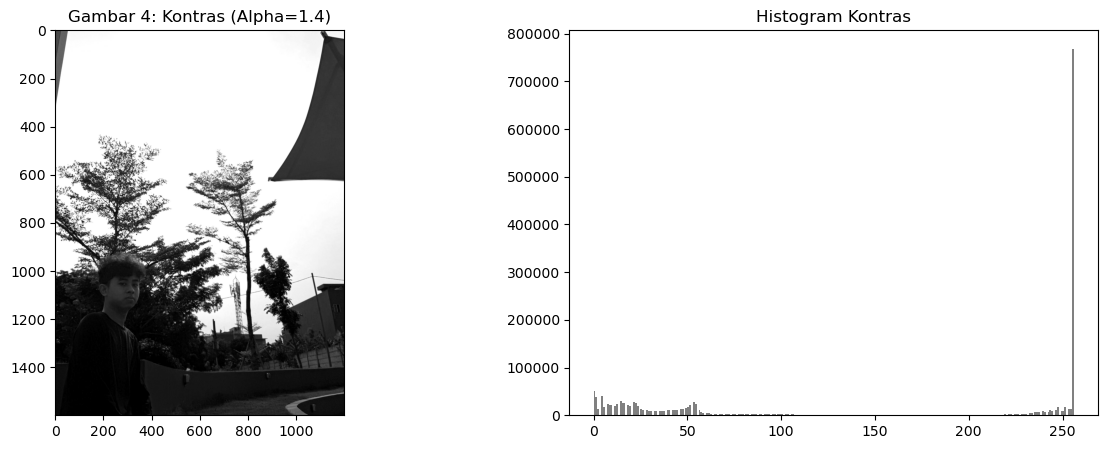

In [6]:
alpha = 1.4
citra_kontras = np.zeros((baris, kolom), dtype=np.float64)

for x in range(baris):
    for y in range(kolom):
        gyx = float(gray[x, y]) * alpha
        citra_kontras[x, y] = gyx

citra_kontras = np.clip(citra_kontras, 0, 255).astype(np.uint8)

cv2.imwrite("Gambar_4_Kontras.jpg", citra_kontras)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].imshow(citra_kontras, cmap='gray')
axs[0].set_title(f"Gambar 4: Kontras (Alpha={alpha})")
axs[1].hist(citra_kontras.ravel(), bins=256, range=[0, 256], color='gray')
axs[1].set_title("Histogram Kontras")
plt.show()

### Gambar 5: Operasi Gabungan (Meningkatkan Kontras Gelap, Mengurangi Kontras Terang)

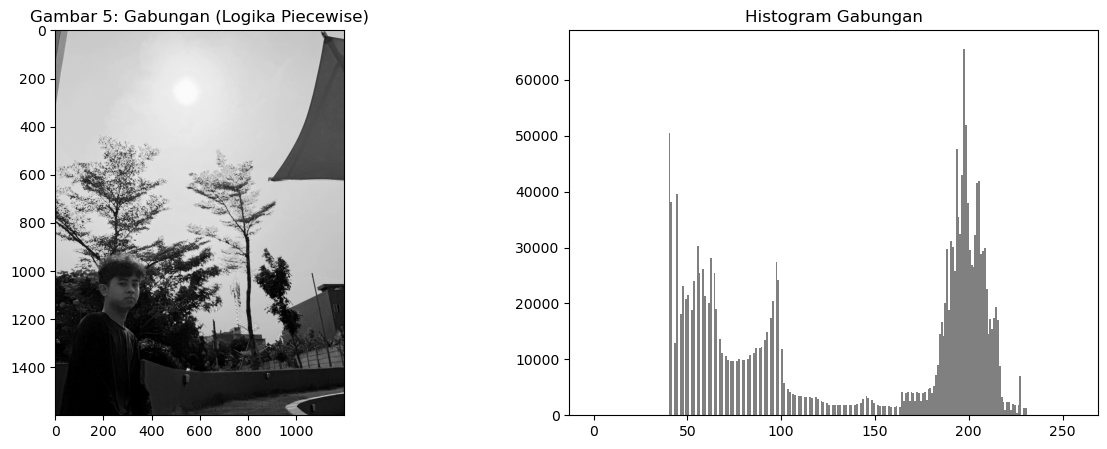

In [7]:
citra_gabungan = np.zeros((baris, kolom), dtype=np.float64)

for x in range(baris):
    for y in range(kolom):
        f = float(gray[x, y])
        
        if f < 128:
            # Area gelap (profil): Alpha besar, Beta besar
            gyx = f * 1.5 + 40
        else:
            # Area terang (langit): Alpha kecil (kurangi kontras), Beta disesuaikan agar nyambung
            gyx = f * 0.5 + 100
            
        citra_gabungan[x, y] = gyx

citra_gabungan = np.clip(citra_gabungan, 0, 255).astype(np.uint8)

cv2.imwrite("Gambar_5_Gabungan.jpg", citra_gabungan)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].imshow(citra_gabungan, cmap='gray')
axs[0].set_title("Gambar 5: Gabungan (Logika Piecewise)")
axs[1].hist(citra_gabungan.ravel(), bins=256, range=[0, 256], color='gray')
axs[1].set_title("Histogram Gabungan")
plt.show()

In [8]:
# Menyimpan Setiap Histogram secara terpisah

# 1. Histogram Gambar Asli
fig_h1 = plt.figure(figsize=(8, 6))
plt.hist(rgb.ravel(), bins=256, range=[0, 256], color='blue')
plt.title("Histogram Gambar Asli")
plt.savefig("Histogram_Gambar_Asli.jpg")
plt.close(fig_h1)

# 2. Histogram Grayscale
fig_h2 = plt.figure(figsize=(8, 6))
plt.hist(gray.ravel(), bins=256, range=[0, 256], color='gray')
plt.title("Histogram Grayscale")
plt.savefig("Histogram_Grayscale.jpg")
plt.close(fig_h2)

# 3. Histogram Kecerahan
fig_h3 = plt.figure(figsize=(8, 6))
plt.hist(citra_cerah.ravel(), bins=256, range=[0, 256], color='gray')
plt.title("Histogram Kecerahan")
plt.savefig("Histogram_Kecerahan.jpg")
plt.close(fig_h3)

# 4. Histogram Kontras
fig_h4 = plt.figure(figsize=(8, 6))
plt.hist(citra_kontras.ravel(), bins=256, range=[0, 256], color='gray')
plt.title("Histogram Kontras")
plt.savefig("Histogram_Kontras.jpg")
plt.close(fig_h4)

# 5. Histogram Gabungan
fig_h5 = plt.figure(figsize=(8, 6))
plt.hist(citra_gabungan.ravel(), bins=256, range=[0, 256], color='gray')
plt.title("Histogram Gabungan")
plt.savefig("Histogram_Gabungan.jpg")
plt.close(fig_h5)

print("Semua histogram berhasil disimpan secara individual!")

Semua histogram berhasil disimpan secara individual!
